# 01 - Data Audit
## Skin Cancer Classification- HAM10000 Dataset

### Objective
This notebook performs an initial audit of the HAM10000 dataset before any modeling step.

The goal is to verify:
 - dataset structure;
 - metadata quality;
 - image availability;
 - class distribution;
 - missing values;
 - duplicate lesions or images;
 - potential data leakage risks.

## 1. Imports

In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

## 2. Projects Paths

In [3]:
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"

IMAGE_DIR_1 = RAW_DIR / "HAM10000_images_part_1"
IMAGE_DIR_2 = RAW_DIR / "HAM10000_images_part_2"

METADATA_PATH = RAW_DIR / "HAM10000_metadata.csv"

## 3. Load Metadata

In [4]:
metadata = pd.read_csv(METADATA_PATH)
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [6]:
metadata.shape

(10015, 7)

In [7]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


## 4. Metadata Overview

In [8]:
metadata.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='str')

In [9]:
metadata.describe(include="all")

,lesion_id,image_id,dx,dx_type,age,sex,localization
count,10015,10015,10015,10015,9958.000000,10015,10015
unique,7470,10015,7,4,NaN,3,15
top,HAM_0003789,ISIC_0027419,nv,histo,NaN,male,back
freq,6,1,6705,5340,NaN,5406,2192
mean,NaN,NaN,NaN,NaN,51.863828,NaN,NaN
std,NaN,NaN,NaN,NaN,16.968614,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,40.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN


In [10]:
expected_columns = [
    "lesion_id",
    "image_id",
    "dx",
    "dx_type",
    "age",
    "sex",
    "localization"
]

set(expected_columns).issubset(metadata.columns)

True

## 5. Missing values

In [11]:
missing_values = metadata.isnull().sum().sort_values(ascending=False)
missing_values

age             57
image_id         0
lesion_id        0
dx               0
dx_type          0
sex              0
localization     0
dtype: int64

In [13]:
missing_percentage = (metadata.isnull().mean()
                      .mul(100).sort_values(ascending=False))
missing_percentage

age             0.569146
image_id        0.000000
lesion_id       0.000000
dx              0.000000
dx_type         0.000000
sex             0.000000
localization    0.000000
dtype: float64

## 6. Class Distribution

In [14]:
class_counts = metadata["dx"].value_counts()
class_counts

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [15]:
class_percentages = metadata["dx"].value_counts(normalize=True).mul(100)
class_percentages

dx
nv       66.949576
mel      11.113330
bkl      10.973540
bcc       5.132302
akiec     3.265102
vasc      1.417873
df        1.148278
Name: proportion, dtype: float64

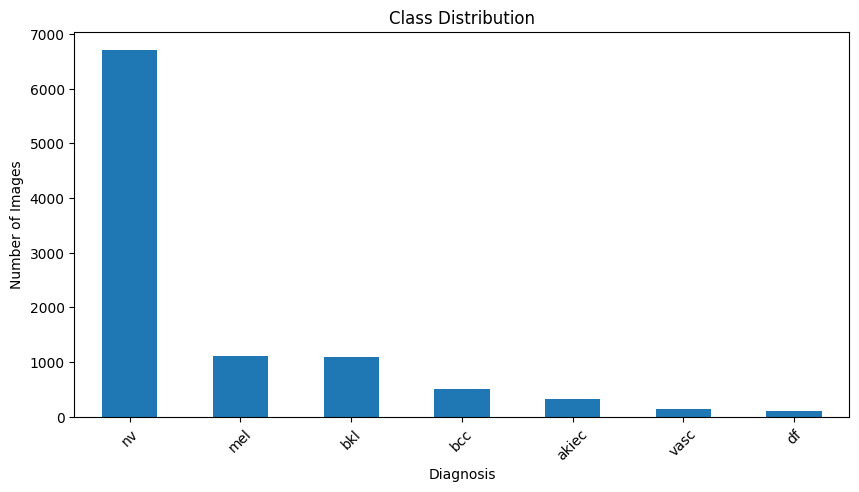

In [16]:
plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

## 7. Diagnosis Label Mapping

In [17]:
dx_mapping =  {
    "akiec": "Actinic keratoses / Bowen's disease",
    "bcc": "Basal cell carcinoma",
    "blk": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": " Melanocytic nevi",
    "vasc": "Vascular lesions"
}

metadata["diagnosis_full"] = metadata["dx"].map(dx_mapping)
metadata[["dx", "diagnosis_full"]].drop_duplicates().sort_values("dx")

,dx,diagnosis_full
9687,akiec,Actinic keratoses / Bowen's disease
2462,bcc,Basal cell carcinoma
0,bkl,NaN
1095,df,Dermatofibroma
1211,mel,Melanoma
64,nv,Melanocytic nevi
2320,vasc,Vascular lesions


## 8. Image File Availability

In [18]:
image_paths = {}
for image_dir in [IMAGE_DIR_1, IMAGE_DIR_2]:
    for image_path in image_dir.glob("*.jpg"):
        image_paths[image_path.stem] = image_path

len(image_paths)

10015

In [19]:
metadata[image_path] = metadata["image_id"].map(image_paths)
metadata["image_path"].isnull().sum()

KeyError: 'image_path'

In [ ]:
missing_images = metadata[metadata["image_path"].isnull()]
missing_images.head()

## 9. Image Size Audit

In [ ]:
def get_image_size(path):
    with Image.open(path) as img:
        return img.size

sample_paths = metadata["image_path"].dropna().sample(100, random_state=42)
image_sizes =  [get_image_size(path) for path in sample_paths]

Counter(image_sizes)

## 10. Duplicate Audit

In [ ]:
metadata["image_id"].duplicated().sum()

In [ ]:
metadata["lesion_id"].duplicated().sum()

In [ ]:
lesion_counts = metadata["lesion_id"].value_counts()
lesion_counts.head()

Some lesions have multiple images.
This creates a potential data leakage risk if images from teh same lesion appear in both train and test sets.

A lesion-level split should be considered instead of a purely image-level split.

## 11. Patient / Clinical Metadata Distribution

In [ ]:
metadata["sex"].value_counts(dropna=False)

In [ ]:
metadata["localization"].value_counts(dropna=False)

In [ ]:
metadata["age"].describe()

In [ ]:
plt.figure(figsize=(8, 5))
metadata["age"].dropna().hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## 12. Sample Images by Class

In [ ]:
def show_samples_by_class(df, class_col="dx", path_col="image_path", n=3):
    classes = df[class_col].unique()

    for cls in classes:
        sample_df = df[df[class_col] == cls].sample(n, random_state=42)

        plt.figure(figsize=(12, 4))
        for i, (_, row) in enumerate(sample_df.iterrows()):
            img = Image.open(row[path_col])

            plt.subplot(1, n, i + 1)
            plt.imshow(img)
            plt.title(cls)
            plt.axis("off")
        plt.show()

show_samples_by_class(metadata, n=3)

## 13. Data Audit Summary

In [ ]:
audit_summary = {
    "number_of_rows": len(metadata),
    "number_of_unique_images": metadata["image_id"]
}